In [1]:
import torch
from matplotlib import pyplot as plt

from torch_scattering import firstborn, multislice, projection, rytov


# Build a 3D scattering potential with Gaussian blobs arranged along a diagonal line

In [2]:
N_XY = 64
N_Z = 512
PIXEL_SIZE = 1.0  # Angstrom
ENERGY = 100.0  # keV

# Blobs equally spaced along Z, moving left-to-right in X -> a diagonal line
N_BLOBS = 5
Z_POSITIONS = torch.linspace(56, N_Z - 56, N_BLOBS)
X_POSITIONS = torch.linspace(20, N_XY - 20, N_BLOBS)
Y_CENTER = N_XY / 2

BLOBS = [
    {"center": (float(z), Y_CENTER, float(x)), "sigma": 1.0, "amplitude": 300.0}
    for z, x in zip(Z_POSITIONS, X_POSITIONS)
]

In [3]:
def gaussian_blob(
    coords: torch.Tensor, center: tuple[float, float, float], sigma: float, amplitude: float
) -> torch.Tensor:
    """Evaluate an isotropic 3D Gaussian at each point in `coords`."""
    r2 = ((coords - torch.tensor(center)) ** 2).sum(dim=-1)
    return amplitude * torch.exp(-r2 / (2 * sigma**2))

In [4]:
zz, yy, xx = torch.meshgrid(
    torch.arange(N_Z), torch.arange(N_XY), torch.arange(N_XY), indexing="ij"
)
coords = torch.stack([zz, yy, xx], dim=-1).float()

potential = torch.zeros(N_Z, N_XY, N_XY)
for blob in BLOBS:
    potential += gaussian_blob(coords, **blob)

# multislice expects a complex-valued potential, batched as (B, Z, Y, X)
potential = potential.to(torch.complex64)[None]
potential.shape

torch.Size([1, 512, 64, 64])

take a look at the central Y-slice of the potential (Z vs X) to see the diagonal line of blobs

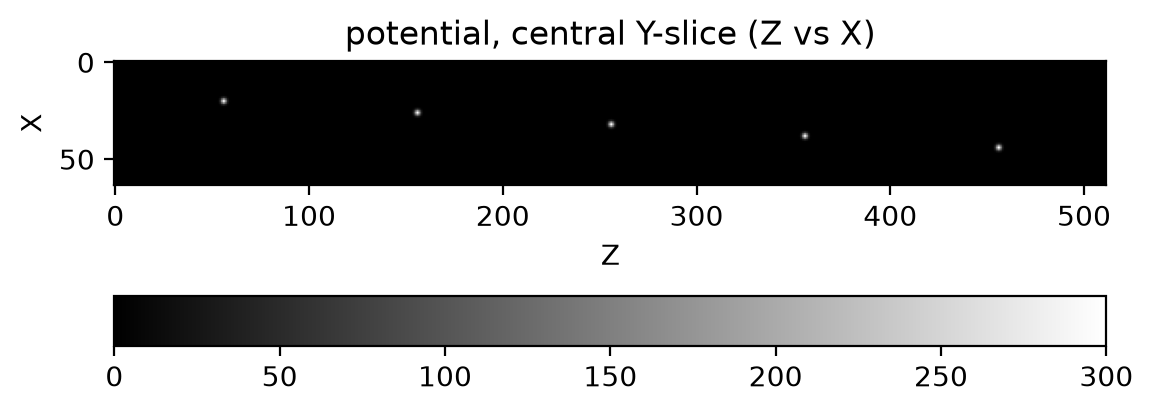

In [5]:
fig, ax = plt.subplots(dpi=200)
im = ax.imshow(potential[0, :, N_XY // 2, :].real.T, cmap="gray", aspect="auto")
ax.set_title("potential, central Y-slice (Z vs X)")
ax.set_xlabel("Z")
ax.set_ylabel("X")
fig.colorbar(im, ax=ax, location='bottom')
ax.set_aspect(1)
plt.show()

## Compute the exit wave using multislice, rytov, first Born, and projection approximations

In [6]:
multislice_wave = multislice(potential, pixel_size=PIXEL_SIZE, energy=ENERGY)
rytov_wave = rytov(potential, pixel_size=PIXEL_SIZE, energy=ENERGY)
firstborn_wave = firstborn(potential, pixel_size=PIXEL_SIZE, energy=ENERGY)
projection_wave = projection(potential, pixel_size=PIXEL_SIZE, energy=ENERGY)

multislice_wave.shape, rytov_wave.shape, firstborn_wave.shape, projection_wave.shape

(torch.Size([1, 64, 64]),
 torch.Size([1, 64, 64]),
 torch.Size([1, 64, 64]),
 torch.Size([1, 64, 64]))

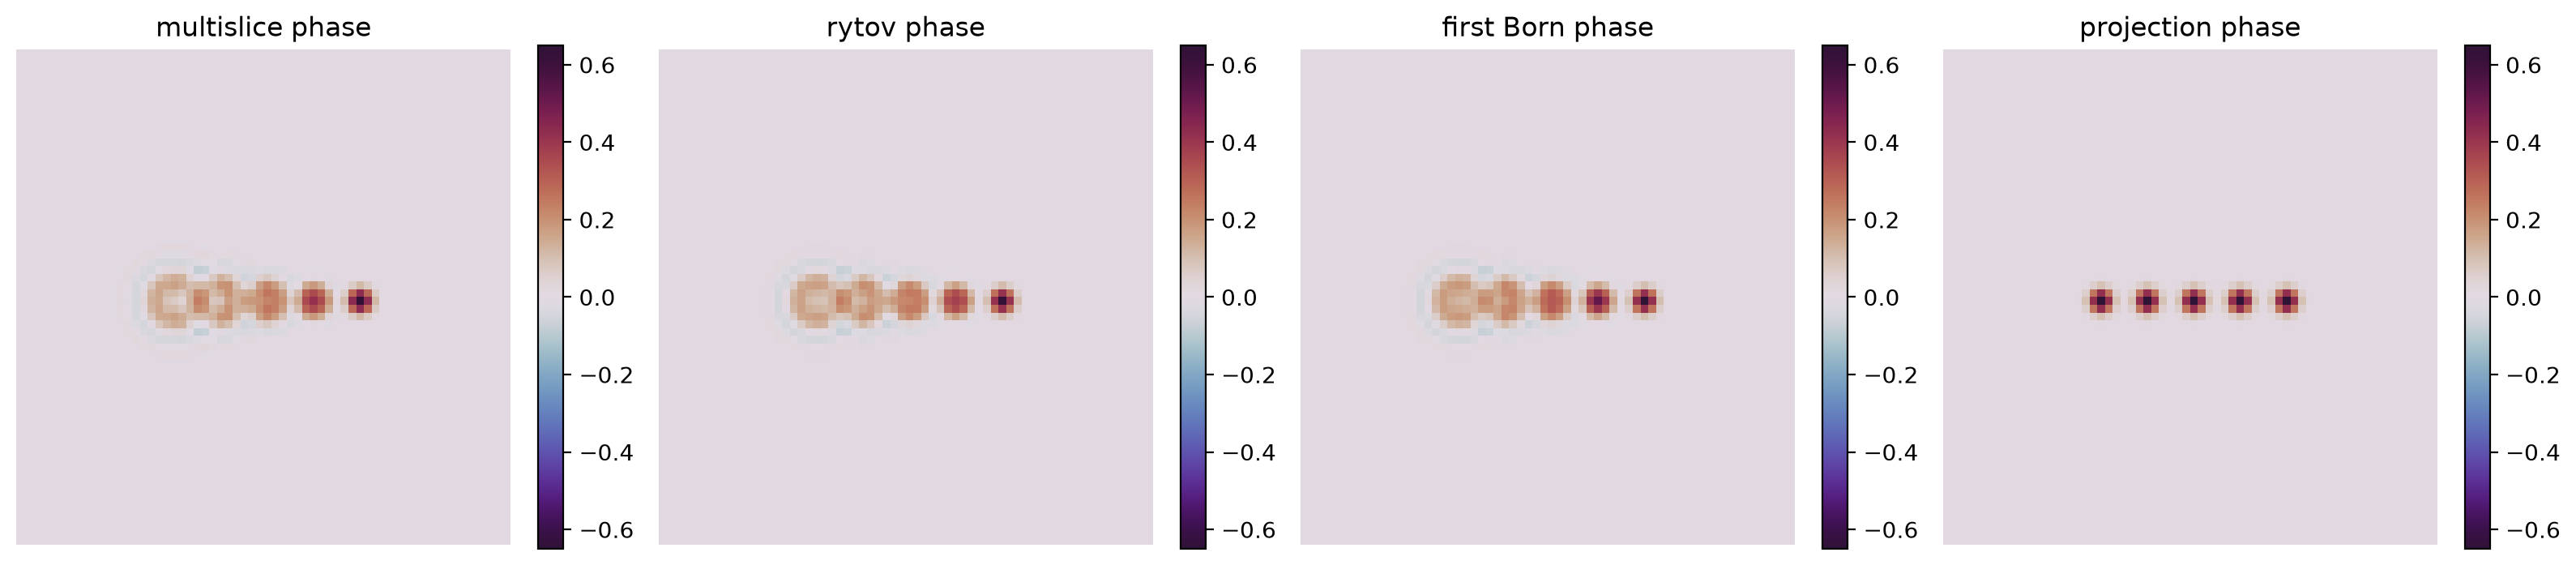

In [7]:
waves = {
    "multislice": multislice_wave,
    "rytov": rytov_wave,
    "first Born": firstborn_wave,
    "projection": projection_wave,
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4), dpi=200)
for ax, (name, wave) in zip(axes, waves.items()):
    im = ax.imshow(wave[0].angle(), cmap="twilight_shifted", vmin=-0.65, vmax=0.65)
    ax.set_title(f"{name} phase")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()